# SVM Experiment

This notebook performs an experiment to study the behavior of Support Vector Machines (SVMs) with varying dimensionality, using scikit-learn's `SVC`.


Dimensionality D=2  done (30 seeds)
Dimensionality D=3  done (30 seeds)
Dimensionality D=4  done (30 seeds)
Dimensionality D=5  done (30 seeds)
Dimensionality D=6  done (30 seeds)
Dimensionality D=7  done (30 seeds)
Dimensionality D=8  done (30 seeds)
Dimensionality D=9  done (30 seeds)
Dimensionality D=10  done (30 seeds)
Dimensionality D=11  done (30 seeds)
Dimensionality D=12  done (30 seeds)
Dimensionality D=13  done (30 seeds)
Dimensionality D=14  done (30 seeds)
Dimensionality D=15  done (30 seeds)
Dimensionality D=16  done (30 seeds)
Dimensionality D=17  done (30 seeds)
Dimensionality D=18  done (30 seeds)
Dimensionality D=19  done (30 seeds)
Dimensionality D=20  done (30 seeds)
Dimensionality D=21  done (30 seeds)

Aggregated results (cuML SVM):
 dimensions  mean_C     std_C  mean_gap  std_gap  mean_acc  std_acc  modal_C modal_gamma  modal_count
          2    75.7 41.015682  0.000308 0.012364  0.937633 0.042617      100         1.0           18
          3    57.1 46.716570  0

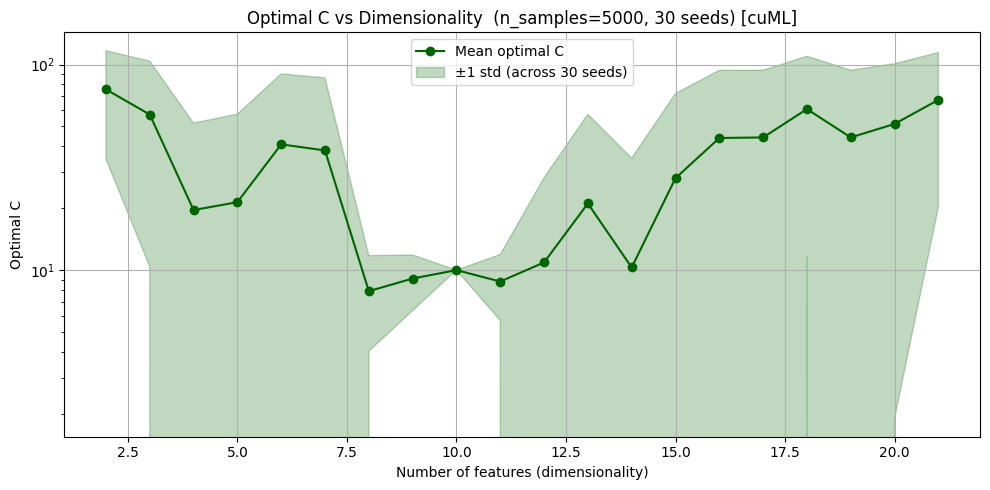

Saved: cuml_svm_optimal_C_vs_dims.png


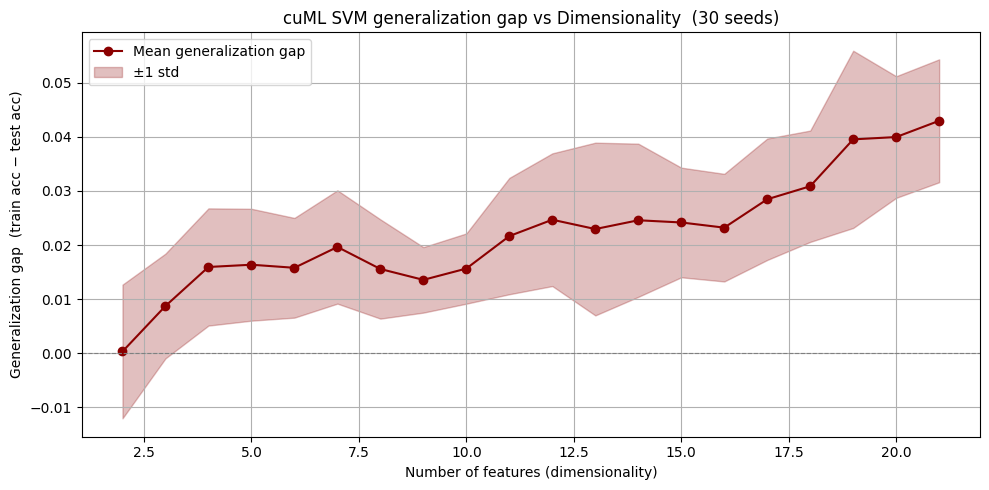

Saved: cuml_svm_gen_gap_vs_dims.png


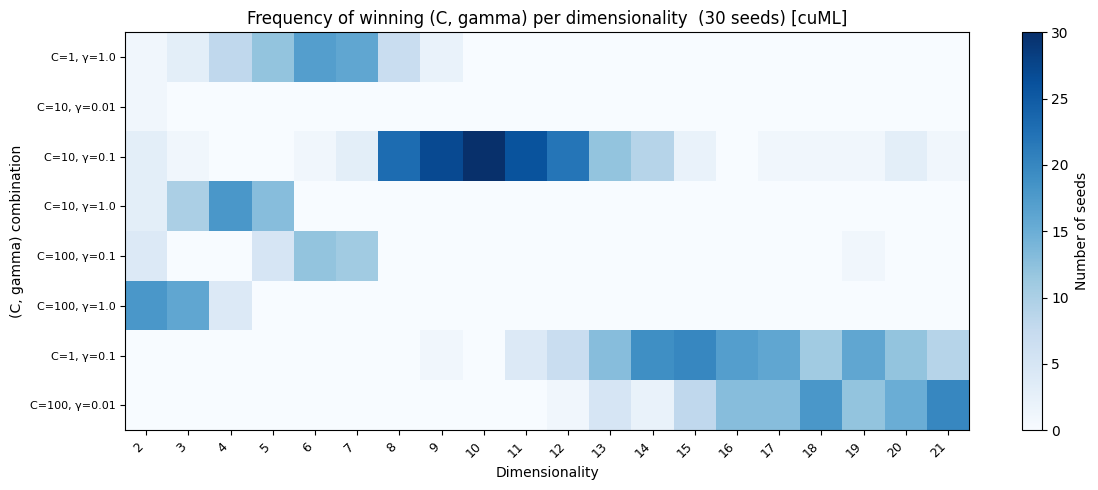

Saved: cuml_svm_combo_heatmap.png
Saved: cuml_svm_raw_results.csv, cuml_svm_aggregated_results.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from cuml.svm import SVC # Changed to cuml.svm.SVC
from cuml.preprocessing import StandardScaler # Changed to cuml.preprocessing.StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split

# ---------------------------------------------------------------
# Experiment parameters
# ---------------------------------------------------------------
N_SAMPLES   = 5000
N_SEEDS     = 30
DIMENSIONS  = np.linspace(2, 21, 20, dtype=int)   # 20 evenly spaced values
C_RANGE     = [0.01, 0.1, 1, 10, 100]             # meaningful range post-scaling
# GAMMA_RANGE = ['scale', 0.001, 0.01, 0.1] # 'scale' is not directly supported by cuml.SVC in GridSearchCV
GAMMA_RANGE = [0.001, 0.01, 0.1, 1.0] # Adjusted for numerical gamma values
CV_FOLDS    = 5

# ---------------------------------------------------------------
# Storage
# ---------------------------------------------------------------
results = []   # one row per (dimension, seed)

# ---------------------------------------------------------------
# Main loop
# ---------------------------------------------------------------
for D in DIMENSIONS:
    print(f"Dimensionality D={D}  ", end="", flush=True)
    D = int(D)

    for seed in range(N_SEEDS):
        X, y = make_classification(
            n_samples=N_SAMPLES,
            n_features=D,
            n_informative=min(D, 10),
            n_redundant=0,
            random_state=seed
        )

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=seed
        )

        # Note: SVC has no random_state parameter — it is deterministic
        pipeline = make_pipeline(StandardScaler(), SVC()) # Using cuml.SVC and cuml.StandardScaler

        param_grid = {
            "svc__C":     C_RANGE,
            "svc__gamma": GAMMA_RANGE
        }
        # Removed n_jobs=-1 as cuml models use GPU internally for parallelism
        gs = GridSearchCV(pipeline, param_grid, cv=CV_FOLDS, scoring="accuracy")
        gs.fit(X_train, y_train)

        best_C     = gs.best_params_["svc__C"]
        best_gamma = gs.best_params_["svc__gamma"]

        # Refit best model to compute generalization gap
        best_pipe = make_pipeline(StandardScaler(), # Using cuml.StandardScaler
                                  SVC(C=best_C, gamma=best_gamma)) # Using cuml.SVC
        best_pipe.fit(X_train, y_train)
        train_acc = best_pipe.score(X_train, y_train)
        test_acc  = best_pipe.score(X_test,  y_test)
        gen_gap   = train_acc - test_acc

        results.append({
            "dimensions": D,
            "seed":       seed,
            "best_C":     best_C,
            "best_gamma": str(best_gamma),   # str for consistency, though now all are floats
            "train_acc":  train_acc,
            "test_acc":   test_acc,
            "gen_gap":    gen_gap,
        })

    print(f"done ({N_SEEDS} seeds)")

# ---------------------------------------------------------------
# Aggregate over seeds
# ---------------------------------------------------------------
df = pd.DataFrame(results)

# Numeric aggregation (gamma stored as str, so aggregate C and gap only)
agg = (df.groupby("dimensions")
         .agg(
             mean_C    =("best_C",    "mean"),
             std_C     =("best_C",    "std"),
             mean_gap  =("gen_gap",   "mean"),
             std_gap   =("gen_gap",   "std"),
             mean_acc  =("test_acc",  "mean"),
             std_acc   =("test_acc",  "std"),
         )
         .reset_index())

# Modal (C, gamma) combination per dimensionality
modal = (df.groupby(["dimensions", "best_C", "best_gamma"])
           .size()
           .reset_index(name="count")
           .sort_values(["dimensions", "count"], ascending=[True, False])
           .drop_duplicates("dimensions")
           .rename(columns={"best_C": "modal_C", "best_gamma": "modal_gamma",
                             "count": "modal_count"}))

agg = agg.merge(modal[["dimensions", "modal_C", "modal_gamma", "modal_count"]],
                on="dimensions")

print("\nAggregated results (cuML SVM):") # Updated print statement
print(agg.to_string(index=False))

# ---------------------------------------------------------------
# Plot 1: Optimal C vs Dimensionality
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(agg["dimensions"], agg["mean_C"],
        marker="o", color="darkgreen", label="Mean optimal C")
ax.fill_between(agg["dimensions"],
                agg["mean_C"] - agg["std_C"],
                agg["mean_C"] + agg["std_C"],
                alpha=0.25, color="darkgreen", label="±1 std (across 30 seeds)")
ax.set_xlabel("Number of features (dimensionality)")
ax.set_ylabel("Optimal C")
ax.set_yscale("log")
ax.set_title(f"Optimal C vs Dimensionality  (n_samples={N_SAMPLES}, {N_SEEDS} seeds) [cuML]") # Updated title
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("cuml_svm_optimal_C_vs_dims.png", dpi=150)
plt.show()
print("Saved: cuml_svm_optimal_C_vs_dims.png") # Updated print statement

# ---------------------------------------------------------------
# Plot 2: Generalization gap vs Dimensionality
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(agg["dimensions"], agg["mean_gap"],
        marker="o", color="darkred", label="Mean generalization gap")
ax.fill_between(agg["dimensions"],
                agg["mean_gap"] - agg["std_gap"],
                agg["mean_gap"] + agg["std_gap"],
                alpha=0.25, color="darkred", label="±1 std")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Number of features (dimensionality)")
ax.set_ylabel("Generalization gap  (train acc − test acc)")
ax.set_title(f"cuML SVM generalization gap vs Dimensionality  ({N_SEEDS} seeds)") # Updated title
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("cuml_svm_gen_gap_vs_dims.png", dpi=150)
plt.show()
print("Saved: cuml_svm_gen_gap_vs_dims.png") # Updated print statement

# ---------------------------------------------------------------
# Plot 3: Modal (C, gamma) heatmap — how often each combo wins
# ---------------------------------------------------------------
combo_counts = (df.groupby(["dimensions", "best_C", "best_gamma"])
                  .size()
                  .reset_index(name="count"))

pivot_data = {}
for _, row in combo_counts.iterrows():
    label = f"C={row['best_C']}, γ={row['best_gamma']}"
    if label not in pivot_data:
        pivot_data[label] = {}
    pivot_data[label][row["dimensions"]] = row["count"]

pivot_df = pd.DataFrame(pivot_data).fillna(0)
pivot_df = pivot_df.loc[sorted(pivot_df.index)]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot_df.T.values, aspect="auto", cmap="Blues",
               interpolation="nearest")
ax.set_xticks(range(len(pivot_df.index)))
ax.set_xticklabels(pivot_df.index, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot_df.columns)))
ax.set_yticklabels(pivot_df.columns, fontsize=8)
ax.set_xlabel("Dimensionality")
ax.set_ylabel("(C, gamma) combination")
ax.set_title(f"Frequency of winning (C, gamma) per dimensionality  ({N_SEEDS} seeds) [cuML]") # Updated title
plt.colorbar(im, ax=ax, label="Number of seeds")
plt.tight_layout()
plt.savefig("cuml_svm_combo_heatmap.png", dpi=150)
plt.show()
print("Saved: cuml_svm_combo_heatmap.png") # Updated print statement

# ---------------------------------------------------------------
# Save raw results
# ---------------------------------------------------------------
df.to_csv("cuml_svm_raw_results.csv", index=False) # Updated filename
agg.to_csv("cuml_svm_aggregated_results.csv", index=False) # Updated filename
print("Saved: cuml_svm_raw_results.csv, cuml_svm_aggregated_results.csv") # Updated print statement
